# MindCare AI ? Depression Dataset: Controlled 3-Model Comparison

This Colab notebook trains and compares **RoBERTa-base, DistilBERT-base, and DeBERTa-v3-base** on the project's prepared binary depression dataset. It uses the same train/validation/test CSV splits and training protocol for all three models.

**Task labels:** `0 = No Depression`, `1 = Depression`.

**Selection rule:** choose the model with the highest **validation Macro-F1**. The test split is evaluated only after selection and is reported descriptively; do not use it to tune or select a model.

The notebook expects `train.csv`, `validation.csv`, and `test.csv` in the Drive dataset folder configured below. Each CSV must have `text,label` columns, using the existing project splits. It saves model artifacts and evaluation evidence to Google Drive.

> This is a text classification/research tool, not a diagnosis, clinical risk score, or substitute for professional mental-health assessment.

In [9]:
# Install pinned, compatible packages while allowing pip to dynamically resolve secondary dependencies.
!pip -q install \
    "transformers==4.57.1" \
    "accelerate==1.10.1" \
    "datasets>=3.0,<4" \
    "sentencepiece>=0.2.0" \
    "scikit-learn>=1.5,<2" \
    "pandas>=2.2,<3" \
    "numpy>=1.26,<3" \
    "matplotlib>=3.8,<4" \
    "seaborn>=0.13" \
    "openpyxl>=3.1,<4" \
    "tabulate>=0.9"

In [2]:
import os, sys, json, math, time, random, shutil, inspect, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, Trainer, TrainingArguments,
                          EarlyStoppingCallback, set_seed)

warnings.filterwarnings("ignore")
print("Python:", sys.version)
print("PyTorch:", torch.__version__, "Transformers:", transformers.__version__)
if not torch.cuda.is_available():
    raise RuntimeError("Select a GPU in Colab: Runtime > Change runtime type > T4 GPU, then rerun.")
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130 Transformers: 4.57.1
GPU: Tesla T4
VRAM (GB): 15.64


In [5]:
from google.colab import drive, files

# Avoid calling mount again when this Colab session already has Drive mounted.
if not Path("/content/drive/MyDrive").is_dir():
    drive.mount("/content/drive")
else:
    print("Google Drive is already mounted; continuing without remounting.")

# Experiment outputs and uploaded dataset files live here in Google Drive.
BASE_DIR = Path("/content/drive/MyDrive/MindCare_Depression_3_Model_Comparison")
DATA_DIR = BASE_DIR / "dataset"
DIRS = {
    "models": BASE_DIR / "models",
    "checkpoints": BASE_DIR / "checkpoints",
    "logs": BASE_DIR / "logs",
    "results": BASE_DIR / "results",
    "reports": BASE_DIR / "reports",
    "plots": BASE_DIR / "plots",
}
for directory in [DATA_DIR, *DIRS.values()]:
    directory.mkdir(parents=True, exist_ok=True)

CSV_PATHS = {split: DATA_DIR / f"{split}.csv" for split in ("train", "validation", "test")}
missing = [split for split, path in CSV_PATHS.items() if not path.is_file()]
if missing:
    print("The prepared CSV split(s) are not in the Drive dataset folder yet.")
    print("Select all three files from your computer when the upload dialog opens.")
    print("They are in your project at: backend/datasets/depression_v2/processed/")
    uploaded = files.upload()
    uploaded_by_name = {Path(name).name.lower(): content for name, content in uploaded.items()}
    for split in missing:
        expected_name = f"{split}.csv"
        if expected_name in uploaded_by_name:
            CSV_PATHS[split].write_bytes(uploaded_by_name[expected_name])

missing = [str(path) for path in CSV_PATHS.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Required CSV splits are still missing. Upload train.csv, validation.csv, "
        "and test.csv from backend/datasets/depression_v2/processed/; expected paths:\n"
        + "\n".join(missing)
    )

print("Experiment folder:", BASE_DIR)
print("Dataset files:")
for split, path in CSV_PATHS.items():
    print(f"  {split:10s} {path} ({path.stat().st_size:,} bytes)")

Google Drive is already mounted; continuing without remounting.
The prepared CSV split(s) are not in the Drive dataset folder yet.
Select all three files from your computer when the upload dialog opens.
They are in your project at: backend/datasets/depression_v2/processed/


Saving validation.csv to validation.csv
Experiment folder: /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison
Dataset files:
  train      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/dataset/train.csv (1,955,902 bytes)
  validation /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/dataset/validation.csv (386,791 bytes)
  test       /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/dataset/test.csv (430,237 bytes)


## Dataset provenance and labels

Use the repository's existing `backend/datasets/depression_v2/processed/{train,validation,test}.csv` files. Upload those exact three files to the Drive folder above; do not merge or resplit them for this controlled comparison.

The existing split sizes are expected to be 5,355 train / 1,147 validation / 1,148 test. The cells below validate columns, labels, missing text, and class distributions, and will report actual counts if your files differ.

In [6]:
SEED = 42
LABEL_NAMES = {0: "No Depression", 1: "Depression"}
ID2LABEL = {int(k): v for k, v in LABEL_NAMES.items()}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
NUM_LABELS = 2

DATASET_NAME = "MindCare prepared depression_v2 CSV splits"
MODELS = {
    "roberta_base": "roberta-base",
    "distilbert_base": "distilbert-base-uncased",
    "deberta_v3_base": "microsoft/deberta-v3-base",
}

# Keep these identical across the three model runs.
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2  # effective train batch size = 16
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
EARLY_STOPPING_PATIENCE = 2
USE_FP16 = True
PRIMARY_SELECTION_METRIC = "eval_macro_f1"

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CONFIG = {
    "dataset": DATASET_NAME, "labels": ID2LABEL, "models": MODELS,
    "seed": SEED, "max_length": MAX_LENGTH, "learning_rate": LEARNING_RATE,
    "epochs": NUM_EPOCHS, "train_batch_size_per_device": TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "effective_train_batch_size": TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
    "eval_batch_size": EVAL_BATCH_SIZE, "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO, "selection_metric": PRIMARY_SELECTION_METRIC,
}
with open(DIRS["reports"] / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2)
print(json.dumps(CONFIG, indent=2))

{
  "dataset": "MindCare prepared depression_v2 CSV splits",
  "labels": {
    "0": "No Depression",
    "1": "Depression"
  },
  "models": {
    "roberta_base": "roberta-base",
    "distilbert_base": "distilbert-base-uncased",
    "deberta_v3_base": "microsoft/deberta-v3-base"
  },
  "seed": 42,
  "max_length": 128,
  "learning_rate": 2e-05,
  "epochs": 3,
  "train_batch_size_per_device": 8,
  "gradient_accumulation_steps": 2,
  "effective_train_batch_size": 16,
  "eval_batch_size": 32,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "selection_metric": "eval_macro_f1"
}


In [7]:
# Load and validate the three fixed CSV splits.
raw_frames = {}
for split, path in CSV_PATHS.items():
    frame = pd.read_csv(path)
    required = {"text", "label"}
    if not required.issubset(frame.columns):
        raise ValueError(f"{path.name} must contain columns {sorted(required)}; found {list(frame.columns)}")
    frame = frame[["text", "label"]].copy()
    frame["text"] = frame["text"].fillna("").astype(str).str.strip()
    frame["label"] = pd.to_numeric(frame["label"], errors="raise").astype(int)
    if frame["text"].eq("").any():
        raise ValueError(f"{split} contains {int(frame['text'].eq('').sum())} empty text rows")
    unexpected = sorted(set(frame["label"].unique()) - {0, 1})
    if unexpected:
        raise ValueError(f"{split} contains labels other than 0/1: {unexpected}")
    raw_frames[split] = frame.reset_index(drop=True)
    print(f"{split:10s}: {len(frame):,} rows | label counts {frame.label.value_counts().sort_index().to_dict()}")

expected = {"train": 5355, "validation": 1147, "test": 1148}
for split, expected_n in expected.items():
    if len(raw_frames[split]) != expected_n:
        print(f"WARNING: {split} has {len(raw_frames[split]):,} rows, expected {expected_n:,}; verify you uploaded the intended v2 split.")

# Report exact normalized-text overlap between splits (do not silently remove data).
norm = {s: set(df.text.str.lower().str.replace(r"\\s+", " ", regex=True)) for s, df in raw_frames.items()}
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    overlap = len(norm[a] & norm[b])
    print(f"Exact normalized text overlap {a}/{b}: {overlap}")
    if overlap:
        print("  Review possible split leakage before reporting results.")

train     : 5,355 rows | label counts {0: 2722, 1: 2633}
validation: 1,147 rows | label counts {0: 583, 1: 564}
test      : 1,148 rows | label counts {0: 584, 1: 564}
Exact normalized text overlap train/validation: 0
Exact normalized text overlap train/test: 1
  Review possible split leakage before reporting results.
Exact normalized text overlap validation/test: 0


,split,label,label_name,count
0,train,0,No Depression,2722
1,train,1,Depression,2633
2,validation,0,No Depression,583
3,validation,1,Depression,564
4,test,0,No Depression,584
5,test,1,Depression,564


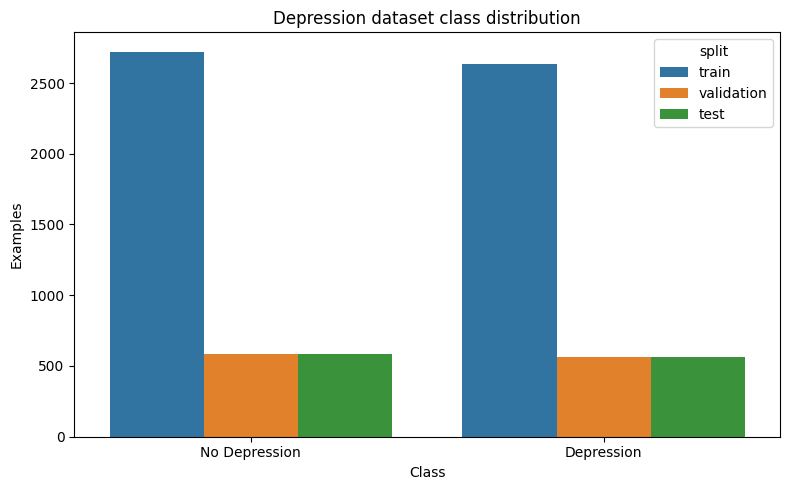

In [8]:
distribution_rows = []
for split, df in raw_frames.items():
    counts = df.label.value_counts().to_dict()
    for label_id, label_name in ID2LABEL.items():
        distribution_rows.append({"split": split, "label": label_id,
                                  "label_name": label_name, "count": int(counts.get(label_id, 0))})
distribution_df = pd.DataFrame(distribution_rows)
distribution_df.to_csv(DIRS["reports"] / "dataset_class_distribution.csv", index=False)
display(distribution_df)
plt.figure(figsize=(8, 5))
sns.barplot(data=distribution_df, x="label_name", y="count", hue="split")
plt.title("Depression dataset class distribution")
plt.xlabel("Class"); plt.ylabel("Examples"); plt.tight_layout()
plt.savefig(DIRS["plots"] / "dataset_class_distribution.png", dpi=200)
plt.show()

In [9]:
# Hugging Face Dataset format used by Trainer; preserve only the provided text/label rows.
hf_data = DatasetDict({
    split: Dataset.from_pandas(frame, preserve_index=False)
    for split, frame in raw_frames.items()
})


def tokenize_for_model(raw_dataset, tokenizer):
    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)
    tokenized = raw_dataset.map(tokenize_batch, batched=True, desc="Tokenizing split")
    tokenized = tokenized.rename_column("label", "labels")
    tokenized = tokenized.remove_columns(["text"])
    return tokenized


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0)
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0)
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "macro_precision": float(p_macro), "macro_recall": float(r_macro),
        "macro_f1": float(f_macro), "weighted_precision": float(p_weighted),
        "weighted_recall": float(r_weighted), "weighted_f1": float(f_weighted),
    }


def build_model(model_name):
    return AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, id2label=ID2LABEL,
        label2id=LABEL2ID, problem_type="single_label_classification")


def json_safe(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, Path): return str(obj)
    raise TypeError(f"Not JSON serializable: {type(obj)}")


def save_json(obj, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=json_safe)

print("Dataset preparation and metric helpers ready.")

Dataset preparation and metric helpers ready.


In [10]:
def make_training_args(model_key):
    model_dir = DIRS["models"] / model_key
    checkpoint_dir = DIRS["checkpoints"] / model_key
    logs_dir = DIRS["logs"] / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    logs_dir.mkdir(parents=True, exist_ok=True)

    steps_per_epoch = math.ceil(len(raw_frames["train"]) /
                                (TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS))
    warmup_steps = int(math.ceil(steps_per_epoch * NUM_EPOCHS * WARMUP_RATIO))
    args = dict(
        output_dir=str(checkpoint_dir), logging_dir=str(logs_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=NUM_EPOCHS, weight_decay=WEIGHT_DECAY,
        warmup_steps=warmup_steps, lr_scheduler_type="linear",
        logging_strategy="epoch", save_strategy="epoch", save_total_limit=2,
        load_best_model_at_end=True, metric_for_best_model=PRIMARY_SELECTION_METRIC,
        greater_is_better=True, fp16=USE_FP16,
        seed=SEED, data_seed=SEED, dataloader_num_workers=2,
        report_to="none", optim="adamw_torch", remove_unused_columns=True,
    )
    params = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" in params:
        args["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in params:
        args["evaluation_strategy"] = "epoch"
    else:
        raise RuntimeError("Installed Transformers does not support evaluation strategy configuration.")
    return TrainingArguments(**args)


def parameter_count(model):
    return sum(p.numel() for p in model.parameters())

In [11]:
def train_one_model(model_key, model_name):
    print("\\n" + "=" * 72 + f"\\nTraining {model_key}: {model_name}\\n" + "=" * 72)
    started = time.time()
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    tokenized = tokenize_for_model(hf_data, tokenizer)
    model = build_model(model_name)
    n_params = parameter_count(model)
    collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

    trainer = Trainer(
        model=model, args=make_training_args(model_key),
        train_dataset=tokenized["train"], eval_dataset=tokenized["validation"],
        processing_class=tokenizer, data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )
    train_output = trainer.train()
    train_metrics = train_output.metrics
    val_metrics = trainer.evaluate(tokenized["validation"], metric_key_prefix="eval")

    # load_best_model_at_end=True ensures this saves the checkpoint chosen by validation Macro-F1.
    model_dir = DIRS["models"] / model_key
    trainer.save_model(str(model_dir))
    tokenizer.save_pretrained(str(model_dir))
    save_json({str(k): v for k, v in ID2LABEL.items()}, model_dir / "label_mapping.json")

    history = []
    for row in trainer.state.log_history:
        history.append({k: (v.item() if isinstance(v, (np.integer, np.floating)) else v)
                        for k, v in row.items()})
    pd.DataFrame(history).to_csv(DIRS["results"] / f"{model_key}_training_history.csv", index=False)
    model_results = {
        "model_key": model_key, "base_model": model_name,
        "parameters": n_params, "parameters_M": n_params / 1e6,
        "training_time_min": (time.time() - started) / 60,
        "train_metrics": train_metrics, "validation_metrics": val_metrics,
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "best_validation_macro_f1": trainer.state.best_metric,
    }
    save_json(model_results, DIRS["results"] / f"{model_key}_training_summary.json")
    del trainer, model, tokenizer, tokenized
    torch.cuda.empty_cache()
    return model_results

print("Training function ready. Models train sequentially to limit GPU memory use.")

Training function ready. Models train sequentially to limit GPU memory use.


## Train all three models

This cell can take a while. It saves each model and its training log to Drive. Keep the runtime connected until each model finishes. If a run is interrupted, rerun only after checking the saved outputs; this notebook does not automatically treat incomplete model folders as completed runs.

In [12]:
all_results = {}
for model_key, model_name in MODELS.items():
    all_results[model_key] = train_one_model(model_key, model_name)
    print("Finished:", model_key, "best validation Macro-F1 =",
          all_results[model_key]["best_validation_macro_f1"])

save_json(all_results, DIRS["reports"] / "all_training_summaries.json")
print("All three training runs completed.")

\n========================================================================\nTraining roberta_base: roberta-base\n========================================================================


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.229900,0.064606,0.980820,0.980891,0.980756,0.980812,0.980841,0.980820,0.980818
2,0.054300,0.112389,0.972973,0.974026,0.972633,0.972937,0.973718,0.972973,0.972953
3,0.018200,0.088404,0.979948,0.979915,0.979986,0.979944,0.979963,0.979948,0.979948


Finished: deberta_v3_base best validation Macro-F1 = 0.9808118137299632
All three training runs completed.


In [13]:
# Select strictly from validation Macro-F1 before calculating held-out test metrics.
comparison_rows = []
for key, result in all_results.items():
    val = result["validation_metrics"]
    comparison_rows.append({
        "model_key": key, "base_model": result["base_model"],
        "parameters_M": result["parameters_M"],
        "validation_accuracy": val.get("eval_accuracy"),
        "validation_macro_precision": val.get("eval_macro_precision"),
        "validation_macro_recall": val.get("eval_macro_recall"),
        "validation_macro_f1": val.get("eval_macro_f1"),
        "validation_weighted_f1": val.get("eval_weighted_f1"),
        "training_time_min": result["training_time_min"],
    })
validation_df = pd.DataFrame(comparison_rows).sort_values(
    "validation_macro_f1", ascending=False).reset_index(drop=True)
selected_row = validation_df.iloc[0]
selected_model_key = selected_row["model_key"]
selected_model_name = selected_row["base_model"]
selection = {
    "selection_rule": "highest validation Macro-F1",
    "selected_model_key": selected_model_key,
    "selected_base_model": selected_model_name,
    "validation_macro_f1": float(selected_row["validation_macro_f1"]),
    "test_set_used_for_selection": False,
}
save_json(selection, DIRS["reports"] / "selected_model.json")
display(validation_df)
print("Selected from validation only:", selected_model_key, selected_model_name)

,model_key,base_model,parameters_M,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_weighted_f1,training_time_min
0,roberta_base,roberta-base,124.647170,0.982563,0.982531,0.982645,0.982561,0.982564,3.738761
1,deberta_v3_base,microsoft/deberta-v3-base,184.423682,0.980820,0.980891,0.980756,0.980812,0.980818,7.428397
2,distilbert_base,distilbert-base-uncased,66.955010,0.975588,0.975562,0.975611,0.975583,0.975589,2.310727


Selected from validation only: roberta_base roberta-base


## Final held-out test evaluation

The validation-selected checkpoint for each model is evaluated once on the test split for the panel comparison. The CSV prediction exports contain row IDs, labels, and confidence only?not depression text?to avoid copying sensitive text into reports.

In [14]:
def evaluate_saved_model(model_key, model_name, split="test"):
    model_dir = DIRS["models"] / model_key
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir), local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir), local_files_only=True)
    model.to("cuda"); model.eval()
    frame = raw_frames[split]
    rows = []
    batch_size = EVAL_BATCH_SIZE
    for start in range(0, len(frame), batch_size):
        batch_texts = frame.text.iloc[start:start + batch_size].tolist()
        inputs = tokenizer(batch_texts, truncation=True, max_length=MAX_LENGTH,
                           padding=True, return_tensors="pt").to("cuda")
        with torch.inference_mode():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=1)
        labels = frame.label.iloc[start:start + len(batch_texts)].to_numpy()
        for offset, (truth, pred, probability) in enumerate(zip(labels, preds, probs)):
            rows.append({
                "row_id": start + offset,
                "true_label": int(truth), "true_class": ID2LABEL[int(truth)],
                "predicted_label": int(pred), "predicted_class": ID2LABEL[int(pred)],
                "confidence": float(probability[int(pred)]),
                "correct": bool(int(truth) == int(pred)),
            })
    pred_df = pd.DataFrame(rows)
    metrics = compute_metrics((
        np.eye(NUM_LABELS)[pred_df.predicted_label.to_numpy()],
        pred_df.true_label.to_numpy()))
    metrics["sample_count"] = int(len(pred_df))
    result_dir = DIRS["results"] / model_key
    result_dir.mkdir(parents=True, exist_ok=True)
    save_json(metrics, result_dir / f"{split}_metrics.json")
    pred_df.to_csv(DIRS["results"] / f"{model_key}_{split}_predictions.csv", index=False)

    report = pd.DataFrame(classification_report(
        pred_df.true_label, pred_df.predicted_label,
        labels=[0, 1], target_names=[ID2LABEL[0], ID2LABEL[1]],
        output_dict=True, zero_division=0)).T
    report.index.name = "class"
    report.reset_index().to_csv(result_dir / f"{split}_classification_report.csv", index=False)
    cm = confusion_matrix(pred_df.true_label, pred_df.predicted_label, labels=[0, 1])
    pd.DataFrame(cm, index=[ID2LABEL[0], ID2LABEL[1]],
                 columns=[ID2LABEL[0], ID2LABEL[1]]).to_csv(result_dir / f"{split}_confusion_matrix.csv")
    del model, tokenizer
    torch.cuda.empty_cache()
    return metrics, pred_df, report, cm

# Selection is already fixed; test metrics below are descriptive only.
test_outputs = {}
for model_key, model_name in MODELS.items():
    test_outputs[model_key] = evaluate_saved_model(model_key, model_name, "test")
    print(model_key, test_outputs[model_key][0])

roberta_base {'accuracy': 0.9817073170731707, 'macro_precision': 0.9818087112871335, 'macro_recall': 0.9816258622364713, 'macro_f1': 0.9816986378739812, 'weighted_precision': 0.9817411151444917, 'weighted_recall': 0.9817073170731707, 'weighted_f1': 0.9817055812333327, 'sample_count': 1148}
distilbert_base {'accuracy': 0.980836236933798, 'macro_precision': 0.9808082279941228, 'macro_recall': 0.9808607791703099, 'macro_f1': 0.9808315244615128, 'weighted_precision': 0.9808432391687165, 'weighted_recall': 0.980836236933798, 'weighted_f1': 0.9808367605418297, 'sample_count': 1148}
deberta_v3_base {'accuracy': 0.9790940766550522, 'macro_precision': 0.9792922418821699, 'macro_recall': 0.9789662877683862, 'macro_f1': 0.9790816326530611, 'weighted_precision': 0.979182150089327, 'weighted_recall': 0.9790940766550522, 'weighted_f1': 0.9790905212259119, 'sample_count': 1148}


In [15]:
# Merge validation and test evidence into the final comparison table.
rows = []
for _, val_row in validation_df.iterrows():
    key = val_row.model_key
    test_metrics = test_outputs[key][0]
    rows.append({**val_row.to_dict(),
                 "test_accuracy": test_metrics["accuracy"],
                 "test_macro_precision": test_metrics["macro_precision"],
                 "test_macro_recall": test_metrics["macro_recall"],
                 "test_macro_f1": test_metrics["macro_f1"],
                 "test_weighted_f1": test_metrics["weighted_f1"]})
comparison_df = pd.DataFrame(rows).sort_values("validation_macro_f1", ascending=False)
comparison_df.to_csv(DIRS["reports"] / "three_model_comparison.csv", index=False)
display(comparison_df)

# Error summary for selected production model, with no raw text.
best_pred = test_outputs[selected_model_key][1]
error_summary = (best_pred.loc[~best_pred.correct]
                 .groupby(["true_class", "predicted_class"]).size()
                 .reset_index(name="count").sort_values("count", ascending=False))
error_summary.to_csv(DIRS["reports"] / "selected_model_error_summary.csv", index=False)
print("Selected-model errors by class pair:")
display(error_summary)

,model_key,base_model,parameters_M,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_weighted_f1,training_time_min,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1
0,roberta_base,roberta-base,124.647170,0.982563,0.982531,0.982645,0.982561,0.982564,3.738761,0.981707,0.981809,0.981626,0.981699,0.981706
1,deberta_v3_base,microsoft/deberta-v3-base,184.423682,0.980820,0.980891,0.980756,0.980812,0.980818,7.428397,0.979094,0.979292,0.978966,0.979082,0.979091
2,distilbert_base,distilbert-base-uncased,66.955010,0.975588,0.975562,0.975611,0.975583,0.975589,2.310727,0.980836,0.980808,0.980861,0.980832,0.980837


Selected-model errors by class pair:


,true_class,predicted_class,count
0,Depression,No Depression,13
1,No Depression,Depression,8


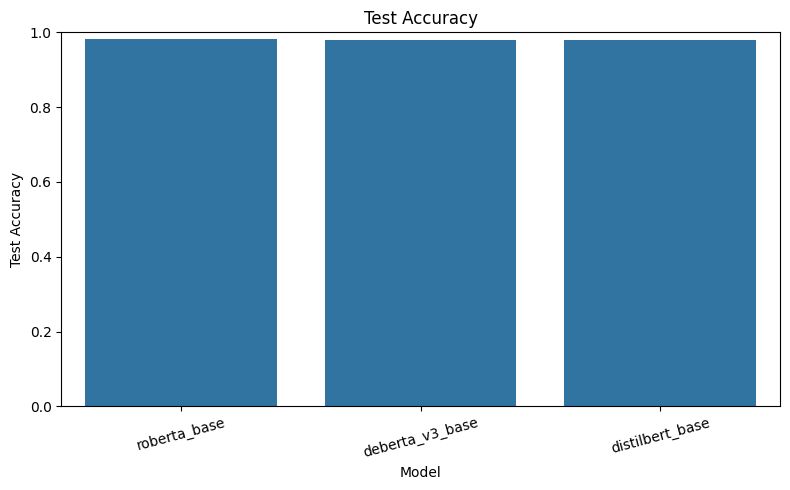

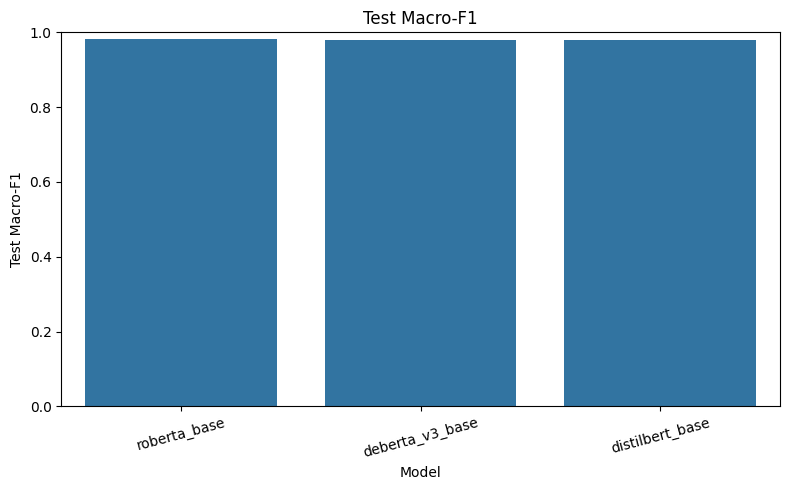

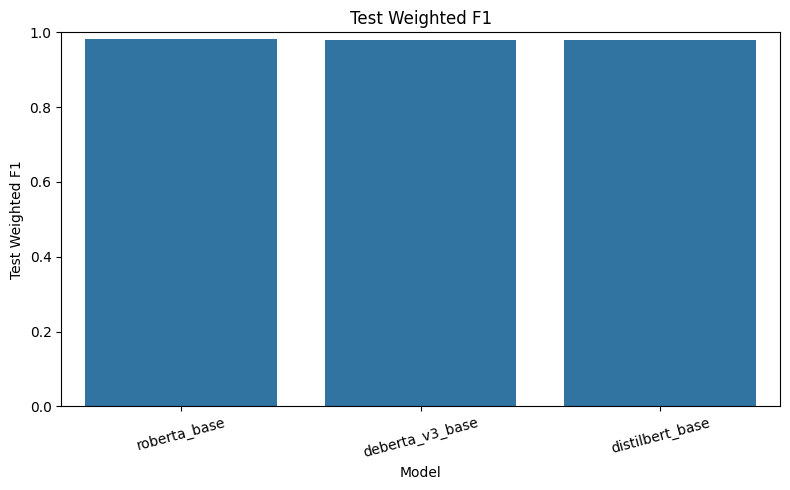

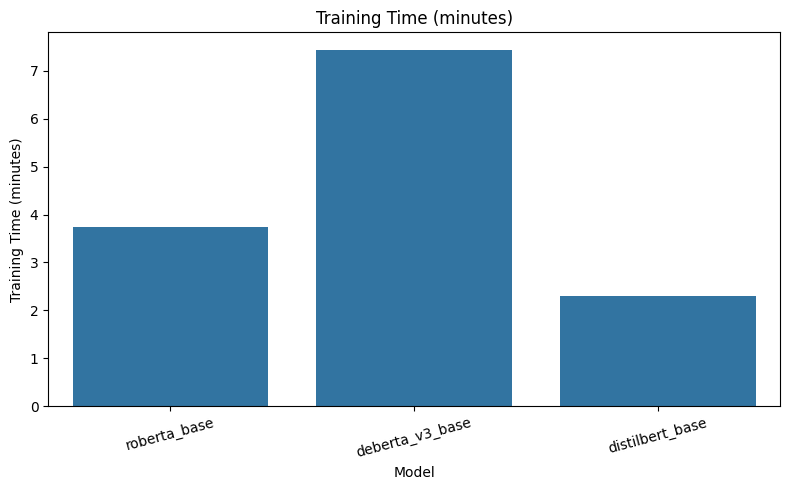

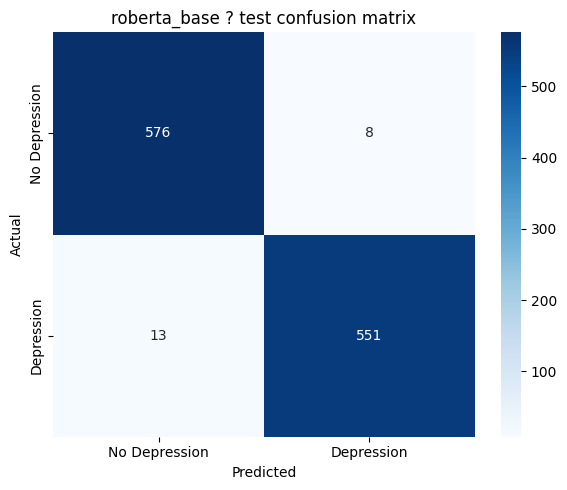

,class,precision,recall,f1-score,support
0,No Depression,0.977929,0.986301,0.982097,584.000000
1,Depression,0.985689,0.976950,0.981300,564.000000
2,accuracy,0.981707,0.981707,0.981707,0.981707
3,macro avg,0.981809,0.981626,0.981699,1148.000000
4,weighted avg,0.981741,0.981707,0.981706,1148.000000


In [16]:
# Compact plots suitable for the panel.
for metric, title in [("test_accuracy", "Test Accuracy"),
                      ("test_macro_f1", "Test Macro-F1"),
                      ("test_weighted_f1", "Test Weighted F1"),
                      ("training_time_min", "Training Time (minutes)")]:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=comparison_df, x="model_key", y=metric)
    if metric != "training_time_min": plt.ylim(0, 1)
    plt.title(title); plt.xlabel("Model"); plt.ylabel(title)
    plt.xticks(rotation=15); plt.tight_layout()
    plt.savefig(DIRS["plots"] / f"comparison_{metric}.png", dpi=200)
    plt.show()

# Confusion matrix and per-class report for the validation-selected model.
_, _, best_report, best_cm = test_outputs[selected_model_key]
plt.figure(figsize=(6, 5))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[ID2LABEL[0], ID2LABEL[1]],
            yticklabels=[ID2LABEL[0], ID2LABEL[1]])
plt.title(f"{selected_model_key} ? test confusion matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout()
plt.savefig(DIRS["plots"] / "selected_model_test_confusion_matrix.png", dpi=200)
plt.show()

selected_test_report = pd.read_csv(DIRS["results"] / selected_model_key / "test_classification_report.csv")
display(selected_test_report)

In [17]:
# Copy only the validation-selected, fine-tuned model to a deployment-ready folder.
production_dir = BASE_DIR / "production_model"
if production_dir.exists():
    shutil.rmtree(production_dir)
shutil.copytree(DIRS["models"] / selected_model_key, production_dir)
production_metadata = {
    **selection,
    "max_length": MAX_LENGTH,
    "label_mapping": {str(k): v for k, v in ID2LABEL.items()},
    "dataset": DATASET_NAME,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "clinical_notice": "Research text classifier only; not a diagnosis or clinical risk assessment.",
}
save_json(production_metadata, production_dir / "production_model_metadata.json")
print("Selected production model:", selected_model_name)
print("Production artifact:", production_dir)
print("Files:", sorted(p.name for p in production_dir.iterdir()))

Selected production model: roberta-base
Production artifact: /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/production_model
Files: ['config.json', 'label_mapping.json', 'merges.txt', 'model.safetensors', 'production_model_metadata.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.json']


In [18]:
# Persist a concise human-readable report and Excel workbook.
report_lines = [
    "# Depression dataset: three-model comparison", "",
    "Task: binary text classification (0 = No Depression, 1 = Depression).",
    "Selection criterion: validation Macro-F1; test set was not used for selection.",
    "",
    f"Selected production model: **{selected_model_name}** ({selected_model_key}).",
    f"Validation Macro-F1: **{selection['validation_macro_f1']:.4f}**.",
    "",
    "## Results", "",
    comparison_df.to_markdown(index=False), "",
    "## Important limitations", "",
    "This is a benchmark on the supplied dataset, not clinical validation. Do not use predictions to diagnose, assess suicide risk, or replace professional care.",
    "Check the split-overlap output and dataset provenance before presenting results.",
]
(DIRS["reports"] / "COMPLETE_EXPERIMENT_REPORT.md").write_text("\\n".join(report_lines), encoding="utf-8")
with pd.ExcelWriter(DIRS["reports"] / "depression_three_model_comparison.xlsx", engine="openpyxl") as writer:
    comparison_df.to_excel(writer, sheet_name="Comparison", index=False)
    distribution_df.to_excel(writer, sheet_name="Class Distribution", index=False)
    selected_test_report.to_excel(writer, sheet_name="Selected Model Test", index=False)
    error_summary.to_excel(writer, sheet_name="Selected Model Errors", index=False)
print((DIRS["reports"] / "COMPLETE_EXPERIMENT_REPORT.md").read_text(encoding="utf-8"))

# Depression dataset: three-model comparison\n\nTask: binary text classification (0 = No Depression, 1 = Depression).\nSelection criterion: validation Macro-F1; test set was not used for selection.\n\nSelected production model: **roberta-base** (roberta_base).\nValidation Macro-F1: **0.9826**.\n\n## Results\n\n| model_key       | base_model                |   parameters_M |   validation_accuracy |   validation_macro_precision |   validation_macro_recall |   validation_macro_f1 |   validation_weighted_f1 |   training_time_min |   test_accuracy |   test_macro_precision |   test_macro_recall |   test_macro_f1 |   test_weighted_f1 |
|:----------------|:--------------------------|---------------:|----------------------:|-----------------------------:|--------------------------:|----------------------:|-------------------------:|--------------------:|----------------:|-----------------------:|--------------------:|----------------:|-------------------:|
| roberta_base    | roberta-base      

In [19]:
# Final artifact checklist
required = [
    production_dir / "config.json", production_dir / "model.safetensors",
    production_dir / "tokenizer.json", production_dir / "tokenizer_config.json",
    production_dir / "production_model_metadata.json",
    DIRS["reports"] / "three_model_comparison.csv",
    DIRS["reports"] / "selected_model.json",
    DIRS["reports"] / "COMPLETE_EXPERIMENT_REPORT.md",
    DIRS["plots"] / "comparison_test_macro_f1.png",
    DIRS["plots"] / "selected_model_test_confusion_matrix.png",
]
for path in required:
    print(("OK      " if path.exists() else "MISSING ") + str(path))
if any(not p.exists() for p in required):
    raise RuntimeError("One or more required output artifacts are missing; inspect errors above.")

OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/production_model/config.json
OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/production_model/model.safetensors
OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/production_model/tokenizer.json
OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/production_model/tokenizer_config.json
OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/production_model/production_model_metadata.json
OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/reports/three_model_comparison.csv
OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/reports/selected_model.json
OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/reports/COMPLETE_EXPERIMENT_REPORT.md
OK      /content/drive/MyDrive/MindCare_Depression_3_Model_Comparison/plots/comparison_test_macro_f1.png
OK      /content/drive/MyDrive/MindCare_Depression_

## What to keep and what to present

Keep this notebook, the three project CSV split files, and the one selected `production_model` folder for deployment. The Drive `models/` directory contains the three fine-tuned candidates for reproducibility; the application only needs `production_model/`.

For the panel, present the controlled protocol, validation-based selection rule, comparison table, training-time comparison, selected model's classification report and confusion matrix, plus the limitations. Be transparent that a benchmark classifier does not diagnose depression or determine clinical risk.